In [1]:
### 1. Importación de Librerías
#En esta primera sección se importan las bibliotecas necesarias para el desarrollo del modelo:
#* **Pandas:** Para la manipulación y lectura del dataset en formato tabular.
#* **Numpy:** Fundamental para las operaciones matemáticas y la manipulación de matrices y vectores.
#* **Matplotlib:** Utilizada para la visualización de los datos y la generación de gráficos de convergencia y dispersión.

import os   
import numpy as np
from matplotlib import pyplot
import matplotlib.pyplot as plt

import pandas as pd


In [2]:
### 2. Carga y Limpieza de Datos
#Se carga el dataset de precios de viviendas (`kc_house_data.csv`). En esta etapa se realiza una limpieza
# inicial eliminando columnas que no aportan información matemática útil para el modelo de regresión, como 
# el identificador único (`id`) y la fecha (`date`). Posteriormente, se extraen los valores a una matriz de 
# Numpy, separando nuestra variable objetivo $y$ (precio de la casa) de nuestra matriz de características $X$.
# 1. Leemos el archivo con pandas en lugar de numpy
df = pd.read_csv('kc_house_data.csv')

# 2. Limpiamos las columnas de texto ('id' y 'date') que no sirven para la matemática
df_limpio = df.drop(['id', 'date'], axis=1)

# 3. Convertimos la tabla a una matriz pura de números de Numpy 
# (Esto hace que la variable 'data' sea exactamente igual a la de tu código original)
data = df_limpio.values

# 4. Separamos X e y
# En este dataset, el precio quedó en la columna 0, y las características desde la columna 1 en adelante
y = data[:, 0]
X = data[:, 1:]
m = y.size

In [3]:
### 3. Verificación de Dimensiones
# Verificamos las dimensiones de la matriz $X$ para asegurarnos de que los datos se han cargado correctamente. 
# Esto nos indica la cantidad de ejemplos de entrenamiento (filas) y el número de características (columnas).

X.shape

(21613, 18)

In [4]:
### 4. Normalización de Características
### Dado que las características del dataset tienen magnitudes muy diferentes (ej. el número de habitaciones
# frente a los pies cuadrados del terreno), es necesario **normalizar** los datos. Esto asegura que el
# algoritmo de Descenso por el Gradiente converja de manera más rápida y estable. La función resta la 
# media ($\mu$) y divide por la desviación estándar ($\sigma$) para cada característica.
                                                   
def normalizarCaracteristicas(X):

    X_norm = X.copy()
    
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])


    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    
    sigma[sigma == 0] = 1 

    X_norm = (X - mu) / sigma
    
    return X_norm, mu, sigma



In [5]:
### 5. Aplicación y Comprobación de la Normalización
# Ejecutamos la función de normalización sobre nuestra matriz de características $X$. Para validar el
# procedimiento, imprimimos los primeros 5 valores de una casa antes y después de ser normalizados, 
# comprobando que ahora se encuentran en un rango mucho más pequeño y manejable para el algoritmo.

# 1. Llamamos a la función con nuestros datos X
X_norm, mu, sigma = normalizarCaracteristicas(X)

# Imprimimos los resultados para verificar
print("Ejemplo de datos originales (primera casa, primeras 5 características):")
print(X[0, :5])
print("\nEjemplo de datos normalizados (misma casa):")
print(X_norm[0, :5])

Ejemplo de datos originales (primera casa, primeras 5 características):
[3.00e+00 1.00e+00 1.18e+03 5.65e+03 1.00e+00]

Ejemplo de datos normalizados (misma casa):
[-0.39873715 -1.44746357 -0.97983502 -0.22832133 -0.915427  ]


In [6]:
### 6. Análisis Exploratorio Visual
# Se define una función auxiliar para graficar la relación entre distintas características 
# independientes frente a la variable dependiente (precio). Se visualizan dos gráficas clave: 
# Precio vs. Superficie Construida, y Precio vs. Número de Dormitorios. Esto nos permite observar
#  la tendencia general (correlación) de los datos normalizados.
def graficarDatos(x, y, xlabel, ylabel):
    fig = plt.figure()

    plt.plot(x, y, 'ro')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.show()

Gráfica 1: Precio vs Superficie Construida


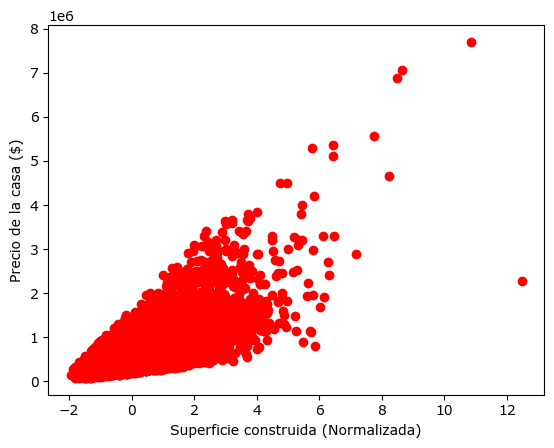

Gráfica 2: Precio vs Número de Dormitorios


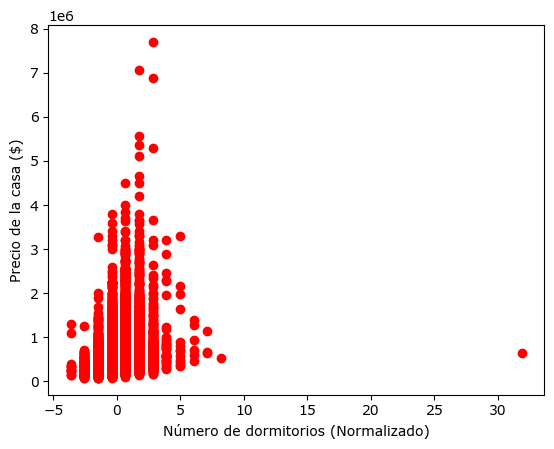

In [7]:
# En nuestro dataset (después de borrar id y fecha):
# El índice 2 corresponde a 'sqft_living' (superficie construida)
# El índice 0 corresponde a 'bedrooms' (número de dormitorios)

xlabel1 = "Superficie construida (Normalizada)"
xlabel2 = "Número de dormitorios (Normalizado)"
ylabel1 = "Precio de la casa ($)"

# 1. Graficamos Precio vs Superficie
print("Gráfica 1: Precio vs Superficie Construida")
graficarDatos(X_norm[:, 2], y, xlabel1, ylabel1)

# 2. Graficamos Precio vs Dormitorios
print("Gráfica 2: Precio vs Número de Dormitorios")
graficarDatos(X_norm[:, 0], y, xlabel2, ylabel1)

In [8]:
### 7. Preparación Final de la Matriz X
# Se concatena una columna llena de unos (1) al inicio de la matriz de características normalizadas. 
# Esta columna corresponde a $x_0$ y permite que nuestro modelo calcule el término de intersección o 
# sesgo ($\theta_0$) durante las operaciones matriciales.

X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)


In [9]:
### 8. Definición y Prueba de la Función de Costo
# Se implementa la Función de Costo $J(\theta)$ basada en el **Error Cuadrático Medio (MSE)**. Esta 
# función matemáticamente evalúa la diferencia entre las predicciones de nuestra hipótesis y los 
# precios reales del dataset. Posteriormente, se realiza una prueba inicial asignando el valor de `0.1`
#  a todos los parámetros $\theta$ para verificar que la función opere correctamente.

def calcularCosto(X, y, theta):
    m = y.size
    J = 0
    # Calculamos la predicción (hipótesis)
    h = np.dot(X, theta)
    # Calculamos el error cuadrático medio
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [10]:

theta_prueba = np.full(X_ready.shape[1], 0.1)

JJ = calcularCosto(X_ready, y, theta_prueba)
print(f"Con theta inventado de prueba se obtiene un costo de: {JJ}")

Con theta inventado de prueba se obtiene un costo de: 213235422877.34262


In [11]:
# Se programa la función iterativa del Descenso por el Gradiente. Este algoritmo busca minimizar la 
# Función de Costo actualizando de manera simultánea todos los parámetros $\theta$ en cada iteración.
# Da pasos proporcionales al gradiente negativo, ajustados por la **tasa de aprendizaje** ($\alpha$).
# Además, se calcula el historial de precisión (R²) en cada iteración.

def calcularDescensoGradiente(X, y, theta, alpha, numero_iteraciones):
    m = y.shape[0]
    # Hacemos una copia para no alterar el theta original
    theta = theta.copy()
    J_historico = []
    R2_historico = []  # NUEVO: Lista para guardar la precisión en cada paso

    # NUEVO: Calculamos la Suma Total de Cuadrados (ss_tot) fuera del ciclo porque no cambia
    y_media = np.mean(y)
    ss_tot = np.sum((y - y_media) ** 2)

    for i in range(numero_iteraciones):
        # Actualización de los parámetros
        theta = theta - (alpha / m) * np.dot(X.T, (np.dot(X, theta) - y))
        
        # Guardamos el costo de esta iteración
        J_historico.append(calcularCosto(X, y, theta))

        # NUEVO: Calculamos las predicciones actuales y la precisión R²
        predicciones_actuales = np.dot(X, theta)
        ss_res = np.sum((y - predicciones_actuales) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        R2_historico.append(r2)

    # NUEVO: Ahora la función devuelve 3 cosas
    return theta, J_historico, R2_historico

print("¡Funciones de Costo, Descenso por el Gradiente y Cálculo de Precisión cargadas con éxito!")

¡Funciones de Costo, Descenso por el Gradiente y Cálculo de Precisión cargadas con éxito!


Los primeros 5 valores de theta calculados son: [540087.98856731 -33143.91165563  31411.23967061  81643.4712548
   5536.25721022]
Con un costo final de: 20234142583.14 

Con una precisión final (R²): 0.6997 



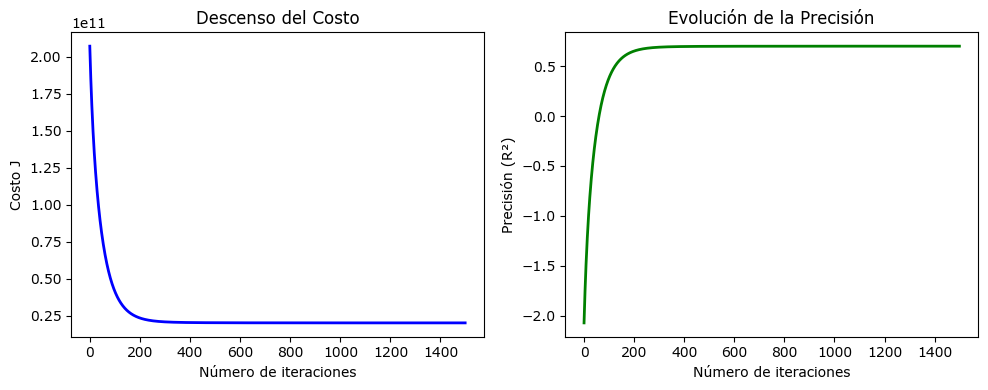

In [12]:
# 1. Inicializamos theta con ceros
theta = np.zeros(X_ready.shape[1])

# 2. Configuración de hiperparámetros
num_ite = 1500
alpha = 0.01

# 3. Entrenamiento del modelo llamando a la nueva función
# Recibimos también el R2_historico
theta_optimo, J_historico, R2_historico = calcularDescensoGradiente(X_ready, y, theta, alpha, num_ite)

print(f"Los primeros 5 valores de theta calculados son: { theta_optimo[:5] }")
print(f"Con un costo final de: { J_historico[-1]:.2f} \n")
print(f"Con una precisión final (R²): { R2_historico[-1]:.4f} \n")

# 4. Gráfica 1: Convergencia del Costo (El error baja)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, posición 1
plt.plot(np.arange(len(J_historico)), J_historico, color='blue', lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Descenso del Costo')

# 5. Gráfica 2: Curva de Precisión (La precisión sube)
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, posición 2
plt.plot(np.arange(len(R2_historico)), R2_historico, color='green', lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Precisión (R²)')
plt.title('Evolución de la Precisión')

plt.tight_layout()
plt.show()

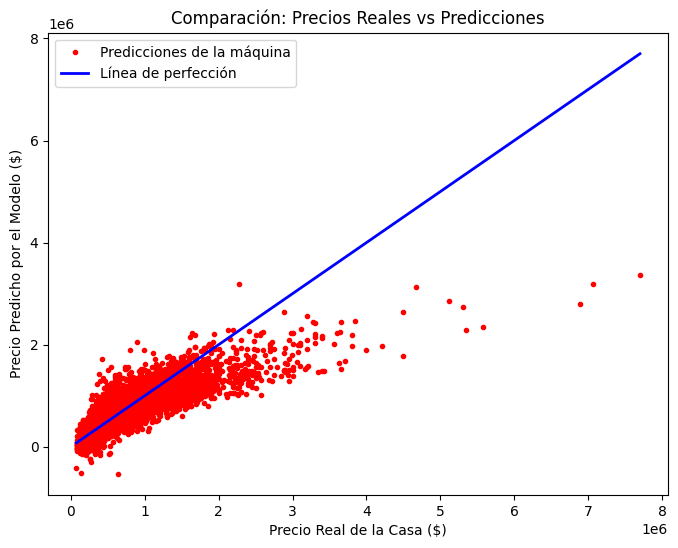

In [19]:

### 11. Evaluación: Predicciones vs Valores Reales
# Para medir visualmente el rendimiento del modelo ya entrenado, generamos predicciones para todas las
# casas del dataset y las comparamos mediante un diagrama de dispersión contra sus precios reales. Se 
# incluye una "Línea de Perfección" ($y = x$) para referenciar qué tan alejadas o cercanas están las 
# predicciones del valor exacto.

# 1. Calculamos las predicciones para todas las casas que la máquina estudió
predicciones = np.dot(X_ready, theta_optimo)

# 2. Graficamos Precio Real vs Precio Predicho
plt.figure(figsize=(8, 6))
# Dibujamos los puntos de nuestras predicciones
plt.plot(y, predicciones, 'ro', ms=3, label='Predicciones de la máquina')

# Dibujamos una línea ideal. 
# Si el modelo fuera 100% perfecto, todos los puntos caerían exactamente sobre esta línea azul.
rango_precios = [y.min(), y.max()]
plt.plot(rango_precios, rango_precios, 'b-', lw=2, label='Línea de perfección')

plt.xlabel('Precio Real de la Casa ($)')
plt.ylabel('Precio Predicho por el Modelo ($)')
plt.title('Comparación: Precios Reales vs Predicciones')
plt.legend()
plt.show()

In [24]:
### 12. Predicción de Nuevos Datos
# Ponemos a prueba el modelo entrenado con los datos de una casa completamente nueva. Es indispensable 
# aplicar los mismos parámetros estadísticos (restar $\mu$ y dividir por $\sigma$) a estas nuevas 
# características antes de realizar la predicción, para que coincidan con la escala del modelo.

casa_nueva = np.array([3, 2.25, 2570, 7242, 2, 0, 0, 3, 7, 2170, 400, 1951, 1991, 98125, 47.7210, -122.319, 1690, 7639], dtype=float)

casa_nueva_norm = (casa_nueva - mu) / sigma

casa_nueva_ready = np.insert(casa_nueva_norm, 0, 1)

precio_gd = np.dot(casa_nueva_ready, theta_optimo)

print(f"Precio predicho (Descenso por el Gradiente): ${precio_gd:,.2f}")

Precio predicho (Descenso por el Gradiente): $735,292.57


Precio predicho (Descenso por el Gradiente): $735,292.57


In [26]:
### 13. Implementación de la Ecuación Normal
# Como alternativa matemática exacta y directa al Descenso por el Gradiente, implementamos la **Ecuación 
# Normal**. Este método calcula los parámetros óptimos $\theta$ en un solo paso mediante álgebra lineal: 
# $\theta = (X^T X)^{-1} X^T y$. La gran ventaja es que *no requiere* normalizar las características ni 
# elegir una tasa de aprendizaje iterativa.

# 1. Definimos la función matemática exacta de tu imagen
def calcularThethaEcuacionNormal(X, y):
    # Fórmula: theta = (X Transpuesta * X) inversa * X Transpuesta * y
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta
# MUY IMPORTANTE: Para este método NO usamos X_norm. Usamos la X original (cruda)
# Solo le agregamos la columna de unos al principio.
X_ren = np.concatenate([np.ones((m, 1)), X], axis=1)

# 3. Calculamos los thetas exactos
theta_normal = calcularThethaEcuacionNormal(X_ren, y)

print("Los primeros 5 valores de theta (Ecuación Normal) son:")
print(theta_normal[:5])

Los primeros 5 valores de theta (Ecuación Normal) son:
[ 1.57745083e+07 -1.17283632e+06 -2.10137777e+06 -9.12078845e+03
 -1.87789456e-01]


In [28]:
### 14. Comparación de Resultados Finales
# Finalmente, calculamos la predicción del precio para la misma casa nueva utilizando el vector $\theta$ 
# obtenido mediante la Ecuación Normal (usando los datos crudos, sin normalizar). Luego, imprimimos ambos 
# resultados juntos para corroborar que el algoritmo de Descenso por el Gradiente se ha acercado 
# satisfactoriamente al valor analítico exacto.

# Casa nueva con datos crudos (solo agregamos el '1' inicial)
casa_nueva_eq_normal = np.insert(casa_nueva, 0, 1)

# Predicción
precio_en = np.dot(casa_nueva_eq_normal, theta_normal)

print(f"Precio predicho (Ecuación Normal):          ${precio_en:,.2f}")
print(f"Precio predicho (Descenso por el Gradiente): ${precio_gd:,.2f}")

Precio predicho (Ecuación Normal):          $2,105,702.57
Precio predicho (Descenso por el Gradiente): $735,292.57
